Summary:
This script sets up the foundational components for building and training a custom deep learning model, likely for image segmentation or detection tasks, using TensorFlow/Keras. Key functionalities include:

Handling file paths (os)

Performing matrix computations (numpy)

Building and training CNNs with various layers like convolution, upsampling, and batch normalization

Preparing data for training using custom Sequence generators

Splitting datasets into training and testing sets

In [ ]:
import os  # Provides functions for interacting with the operating system (e.g., reading file paths)
import numpy as np  # Fundamental package for numerical computing in Python
import tensorflow as tf  # Main deep learning framework used here
from tensorflow.keras.models import Model  # Used to define custom Keras models
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation, 
                                     UpSampling2D, Add, Concatenate)  # Import common layers for building CNNs
from tensorflow.keras.optimizers import Adam  # Optimizer used to minimize loss during training
from tensorflow.keras.utils import Sequence  # Utility for creating custom data generators for model training
from tensorflow.keras import backend as K  # Backend operations (like custom loss functions or metrics)
from tensorflow.keras.preprocessing.image import load_img, img_to_array  # Tools for image loading and conversion
from sklearn.model_selection import train_test_split  # Function to split data into training and testing sets

Summary:
This class creates a custom data generator for PNG images, suitable for training segmentation models like U-Net or HRNet. It:

Loads images and masks in batches.

Resizes and normalizes them.

Handles both labeled (with masks) and unlabeled (without masks) data by using dummy masks.

Supports on-the-fly data shuffling for each epoch.

In [ ]:
# Data Generator for PNG images (used for training models with image and optional mask pairs)
class PNGDataGenerator(Sequence):
    def __init__(self, image_dir, mask_dir=None, batch_size=8, img_size=(128, 128), shuffle=True):
        self.image_dir = image_dir  # Directory containing input images
        self.mask_dir = mask_dir  # Directory containing masks (can be None for unlabeled data)
        self.batch_size = batch_size  # Number of samples per batch
        self.img_size = img_size  # Target size to resize images/masks (width, height)
        self.shuffle = shuffle  # Whether to shuffle data after each epoch
        self.image_files = sorted(os.listdir(image_dir))  # Sorted list of image file names
        self.mask_files = sorted(os.listdir(mask_dir)) if mask_dir else None  # Sorted list of mask file names
        self.on_epoch_end()  # Initialize index list and shuffle if required

    def __len__(self):
        # Returns total number of batches per epoch
        return int(np.floor(len(self.image_files) / self.batch_size))

    def on_epoch_end(self):
        # Updates indices after each epoch for shuffling
        self.indices = np.arange(len(self.image_files))
        if self.shuffle:
            np.random.shuffle(self.indices)  # Shuffle indices if enabled

    def __getitem__(self, index):
        # Generates one batch of data
        indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]  # Get indices for this batch
        batch_images = [self.image_files[k] for k in indices]  # Get file names for the current batch

        images = []  # List to hold image data
        masks = []  # List to hold mask data

        for i, img_file in enumerate(batch_images):
            # Load and normalize image
            img = load_img(os.path.join(self.image_dir, img_file), target_size=self.img_size)  # Load image and resize
            img = img_to_array(img) / 255.0  # Convert to array and normalize to [0, 1]
            images.append(img)

            if self.mask_dir and img_file in self.mask_files:
                # Load and normalize corresponding grayscale mask if available
                mask = load_img(os.path.join(self.mask_dir, img_file), target_size=self.img_size, color_mode="grayscale")
                mask = img_to_array(mask) / 255.0  # Normalize mask to [0, 1]
                masks.append(mask)
            else:
                # If no mask is found (e.g., for non-landslide images), use a dummy zero mask
                masks.append(np.zeros((*self.img_size, 1)))  # Dummy mask with same size

        return np.array(images), np.array(masks)  # Return batch of images and masks as numpy arrays


Summary:
This block is designed to enhance feature representation by combining:

Local features (standard convolution) and

Contextual features (dilated convolution),
which is beneficial for tasks like semantic segmentation or object detection, especially in complex scenes (e.g., landslides).

In [ ]:
# Context Guided Block (CG Block) - captures both local and contextual features
def context_guided_block(input_tensor, out_channels):
    # Local feature extraction using standard 3x3 convolution
    local = Conv2D(out_channels, kernel_size=3, padding='same')(input_tensor)  # Regular 3x3 conv
    local = BatchNormalization()(local)  # Normalize the feature map
    local = Activation('relu')(local)  # Apply ReLU activation

    # Context feature extraction using dilated convolution to capture a wider receptive field
    context = Conv2D(out_channels, kernel_size=3, dilation_rate=2, padding='same')(input_tensor)  # Dilated conv for context
    context = BatchNormalization()(context)  # Normalize the feature map
    context = Activation('relu')(context)  # Apply ReLU activation

    # Fuse local and context features using element-wise addition
    fused = Add()([local, context])  # Combine the local and context branches
    return Activation('relu')(fused)  # Final ReLU activation on the fused output


Summary:
The model starts with an input tensor and applies two Context Guided Blocks to extract rich local and contextual features.

A skip connection is created from an early layer and processed through additional convolution to maintain high-resolution details.

The architecture downscales and processes features (increasing channel depth) before concatenating with skip features.

Finally, after further refinement and upsampling, a 1x1 convolution with sigmoid activation provides the output, suitable for tasks like binary segmentation.

In [ ]:
# LWGANet Model
def LWGANet(input_shape):
    # Define the input tensor with the specified input shape (e.g., height, width, channels)
    inputs = Input(shape=input_shape)

    # First Context Guided Block: captures local and contextual features with 64 filters
    x = context_guided_block(inputs, 64)
    # Second Context Guided Block for deeper feature extraction, still with 64 filters
    x = context_guided_block(x, 64)
    # Save the output here as a "skip connection" to incorporate high-resolution features later
    skip = x

    # Downsample the features using a strided convolution (reduces spatial dimensions by half)
    x = Conv2D(128, kernel_size=3, strides=2, padding='same')(x)
    x = BatchNormalization()(x)  # Normalize the features for stable training
    x = Activation('relu')(x)  # Activate nonlinear features with ReLU
    # Apply a Context Guided Block with 128 filters on the downsampled feature maps to extract contextual information
    x = context_guided_block(x, 128)

    # Process the skip connection: downsample the skip branch to match the size of x
    skip = Conv2D(128, kernel_size=3, strides=2, padding='same')(skip)
    skip = BatchNormalization()(skip)
    skip = Activation('relu')(skip)

    # Concatenate the main branch (x) and the processed skip branch along the channel dimension
    x = Concatenate()([x, skip])
    # Further refine fused features using a Context Guided Block with 64 filters
    x = context_guided_block(x, 64)
    # Regular convolution to refine features with 64 filters using a 3x3 kernel and ReLU activation
    x = Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
    # Upsample the feature maps by a factor of 2 using bilinear interpolation to restore spatial dimensions
    x = UpSampling2D(size=(2, 2), interpolation='bilinear')(x)

    # Final convolution: reduce the number of channels to 1 (e.g., for binary segmentation) and use a sigmoid activation
    x = Conv2D(1, kernel_size=1, activation='sigmoid')(x)
    # Create the model by specifying the inputs and outputs
    model = Model(inputs=inputs, outputs=x)
    return model


Summary:
Dice Loss is ideal for imbalanced data (like small landslide regions) and penalizes both false positives and false negatives.

Dice Coefficient is a similarity measure ranging from 0 (no overlap) to 1 (perfect match), often used as a metric for segmentation tasks.

In [ ]:
# Dice Loss: a commonly used loss function for image segmentation tasks
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)  # Flatten the ground truth mask to a 1D vector
    y_pred_f = K.flatten(y_pred)  # Flatten the predicted mask to a 1D vector
    intersection = K.sum(y_true_f * y_pred_f)  # Compute the intersection between prediction and ground truth
    # Dice loss formula: 1 - Dice coefficient (with smoothing to avoid division by zero)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Dice Coefficient: used as a metric to evaluate the overlap between prediction and ground truth
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.cast(y_true, dtype='float32')  # Ensure y_true is in float32 for consistent computation
    y_pred_f = K.flatten(y_pred)  # Flatten the predicted mask
    y_true_f = K.flatten(y_true_f)  # Flatten the ground truth mask
    intersection = K.sum(y_true_f * y_pred_f)  # Compute intersection
    # Dice coefficient formula (with smoothing)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


In [ ]:
# Define the input shape for the model (e.g., 128x128 RGB images)
input_shape = (128, 128, 3)

# Path to the directory containing input images (PNG format)
image_dir = '/content/drive/MyDrive/data /landdata/landslide/image'  # PNG images

# Path to the directory containing corresponding ground truth masks (PNG format, grayscale)
mask_dir = '/content/drive/MyDrive/data /landdata/landslide/mask'  # PNG masks (optional, may be None)


Summary of the Comments:
Image Directory: Path to the folder that holds the input images.

Mask Directory: Path to the folder that holds the corresponding segmentation masks (optional, and the model can still work without masks).

Batch Size: Set to 10, meaning each batch consists of 10 image-mask pairs.

In [ ]:
# Data Generator Setup
# Create an instance of PNGDataGenerator with the specified directories and batch size
train_gen = PNGDataGenerator(
    image_dir=image_dir,  # Directory containing PNG images
    mask_dir=mask_dir,    # Directory containing PNG masks (optional, can be None)
    batch_size=10         # Set the batch size to 10 (number of image-mask pairs per batch)
)


Summary:
Model Initialization: Creates an instance of the LWGANet with the specified input shape (e.g., 128x128x3 for RGB images).

Model Compilation:

Optimizer: Adam optimizer with a learning rate of 1e-4 for stable training.

Loss Function: Dice loss is used to optimize segmentation accuracy.

Metrics: Tracks accuracy and Dice coefficient to evaluate the model's performance on segmentation tasks.

Model Summary: Prints the model’s architecture, showing layers, number of parameters, and other important details.

In [ ]:
# Model Setup
# Initialize the LWGANet model with the specified input shape (e.g., 128x128 RGB images)
model = LWGANet(input_shape)

# Compile the model with the following configurations:
# - Optimizer: Adam optimizer with a learning rate of 1e-4 (learning rate can be adjusted for model convergence)
# - Loss: Dice loss, which is commonly used for segmentation tasks where the goal is to maximize overlap between prediction and ground truth
# - Metrics: 'accuracy' and 'dice_coefficient' to evaluate model performance during training
model.compile(optimizer=Adam(1e-4), loss=dice_loss, metrics=['accuracy', dice_coefficient])

# Display the summary of the model architecture (layers, parameters, etc.)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ activation[0][0], │
│                     │ 64)               │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 128,  │          0 │ activation_3[0][… │
│                     │ 64)               │            │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 128, 128,  │          0 │ add_1[0][0]     

 Total params: 855,937 (3.27 MB)

 Trainable params: 854,145 (3.26 MB)

 Non-trainable params: 1,792 (7.00 KB)

Summary:
train_gen supplies batches of image-mask pairs.

The model will be trained for 50 epochs, adjusting weights to minimize the Dice loss and improve segmentation performance.

Progress (loss and metrics) will be printed per epoch.

In [ ]:
# Train the model
# Fit the model using the training data generator (train_gen)
# - epochs=50: Train the model for 50 full passes over the training dataset
model.fit(train_gen, epochs=50)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 495s 1s/step - accuracy: 0.8131 - dice_coefficient: 0.1709 - loss: 0.8291
Epoch 2/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 40s 88ms/step - accuracy: 0.9722 - dice_coefficient: 0.2716 - loss: 0.7284
Epoch 3/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 40s 85ms/step - accuracy: 0.9697 - dice_coefficient: 0.2959 - loss: 0.7041
Epoch 4/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 39s 86ms/step - accuracy: 0.9745 - dice_coefficient: 0.3080 - loss: 0.6920
Epoch 5/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 39s 85ms/step - accuracy: 0.9777 - dice_coefficient: 0.3038 - loss: 0.6962
Epoch 6/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 39s 86ms/step - accuracy: 0.9759 - dice_coefficient: 0.3626 - loss: 0.6374
Epoch 7/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.9798 - dice_coefficient: 0.3542 - loss: 0.6458
Epoch 8/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.9785 - dice_coefficient: 0.3322 - loss: 0.6678
Epoch 9/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 39s 85ms/step - accuracy: 0.9784 - dice_c

Summary:
Purpose: Saves your trained LWGANet model so you can load it later for inference or continued training.

Format: The .h5 (HDF5) format is commonly used for saving full Keras models.

In [ ]:
# Save the trained model to Google Drive
# This will store the entire model architecture, weights, and optimizer state in HDF5 format
model.save("/content/drive/MyDrive/data/lwganet_landslide_png1.h5")


Testing on 1209 images...

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

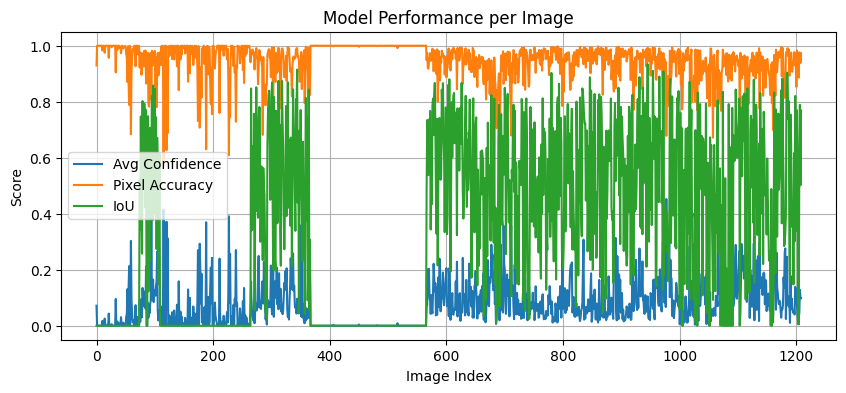

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from glob import glob
import cv2

# Load pre-trained LWGANet model (trained on landslide data)
model_path = "/content/drive/MyDrive/data/lwganet_landslide_png1.h5"
model = load_model(model_path, compile=False)  # We skip compile because we are only predicting

# Define directories
test_dir = "/content/drive/MyDrive/data/land test/images"  # Test images
mask_dir = "/content/drive/MyDrive/data/land test/Masks"   # Ground truth masks (optional)
output_dir = "/content/drive/MyDrive/data/land test/resultsLWANet"  # Where results will be saved
os.makedirs(output_dir, exist_ok=True)  # Create output directory if it doesn't exist

# Load all PNG image paths from test_dir
image_paths = sorted(glob(os.path.join(test_dir, "*.png")))

# Target size to resize images for model input
img_size = (128, 128)

# Function to predict and visualize results for each image
def predict_and_visualize(image_paths, model, img_size, max_images=50):
    print(f"Testing on {len(image_paths)} images...\n")
    avg_confidences = []  # Store average prediction confidence per image
    all_accuracies = []   # Store pixel accuracy for each prediction
    all_ious = []         # Store Intersection over Union for each prediction

    # Iterate through the first max_images in the dataset
    for idx, img_path in enumerate(image_paths[:max_images]):
        img_name = os.path.basename(img_path)
        mask_path = os.path.join(mask_dir, img_name)

        # Load and preprocess image
        img = load_img(img_path, target_size=img_size)       # Load and resize image
        img_array = img_to_array(img) / 255.0                # Normalize to [0, 1]
        input_tensor = np.expand_dims(img_array, axis=0)     # Add batch dimension

        # Load and preprocess ground truth mask (if exists)
        if os.path.exists(mask_path):
            mask = load_img(mask_path, target_size=img_size, color_mode='grayscale')
            mask_array = img_to_array(mask).squeeze() / 255.0      # Normalize mask
            bin_mask = (mask_array > 0.5).astype(np.uint8)         # Convert to binary mask
        else:
            bin_mask = np.zeros(img_size, dtype=np.uint8)          # If no mask, assume empty

        # Predict mask using model
        pred = model.predict(input_tensor)[0, :, :, 0]             # Raw prediction (128x128 float)
        bin_pred = (pred > 0.5).astype(np.uint8)                   # Threshold to binary
        avg_confidence = np.mean(pred)                             # Mean confidence value
        avg_confidences.append(avg_confidence)

        # Calculate pixel-level accuracy
        pixel_accuracy = np.mean(bin_pred == bin_mask)
        all_accuracies.append(pixel_accuracy)

        # Calculate IoU (Intersection over Union)
        intersection = np.logical_and(bin_pred, bin_mask).sum()
        union = np.logical_or(bin_pred, bin_mask).sum()
        iou = intersection / union if union != 0 else 0
        all_ious.append(iou)

        # Draw predicted contours on the original image using OpenCV
        img_cv = (img_array * 255).astype(np.uint8)              # Convert back to 0-255 scale
        img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)         # Convert RGB to BGR for OpenCV
        contours, _ = cv2.findContours(bin_pred, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(img_cv, contours, -1, (0, 0, 255), 1)   # Draw contours in red

        # Plot original image, prediction, and comparison visuals
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        fig.suptitle(f"{img_name} - Conf: {avg_confidence:.3f} - Acc: {pixel_accuracy:.3f} - IoU: {iou:.3f}", fontsize=12)

        axes[0].imshow(img_array)                  # Original image
        axes[0].set_title("Original")
        axes[0].axis('off')

        axes[1].imshow(pred, cmap='jet')           # Raw prediction (confidence map)
        axes[1].set_title("Raw Prediction")
        axes[1].axis('off')

        axes[2].imshow(bin_pred, cmap='gray')      # Predicted binary mask
        axes[2].set_title("Predicted Mask")
        axes[2].axis('off')

        axes[3].imshow(bin_mask, cmap='gray')      # Ground truth mask
        axes[3].set_title("Ground Truth Mask")
        axes[3].axis('off')

        axes[4].imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))  # Contour overlay
        axes[4].set_title("Contours")
        axes[4].axis('off')

        # Save the visualization
        plt.tight_layout()
        result_path = os.path.join(output_dir, f"result_{idx:03d}_{img_name}")
        plt.savefig(result_path)
        plt.close()

    # Plot performance summary graph (Confidence, Accuracy, IoU)
    plt.figure(figsize=(10, 4))
    plt.plot(avg_confidences, label='Avg Confidence')
    plt.plot(all_accuracies, label='Pixel Accuracy')
    plt.plot(all_ious, label='IoU')
    plt.xlabel("Image Index")
    plt.ylabel("Score")
    plt.title("Model Performance per Image")
    plt.legend()
    plt.grid(True)
    graph_path = os.path.join(output_dir, "metrics_plot.png")
    plt.savefig(graph_path)
    plt.show()

# Run prediction and visualization on test images
predict_and_visualize(image_paths, model, img_size, max_images=1600)


 Summary of What This Script Does:
Loads RGB images, optional infrared images, and ground truth masks

Uses LWGANet to predict landslide masks

Draws contours and bounding boxes on detected areas

Combines all results into a side-by-side visualization

Saves the visual outputs to a specified directory

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from glob import glob
import cv2

# Define paths
model_path = "/content/drive/MyDrive/data/lwganet_landslide_png1.h5"  # Trained LWGANet model
test_dir = "/content/drive/MyDrive/data/land test/images"             # RGB test images
mask_dir = "/content/drive/MyDrive/data/land test/Masks"              # Ground truth masks
output_dir = "/content/drive/MyDrive/data/land test/resultsLWANet1"   # Save visual results
infrared_dir = "/content/drive/MyDrive/data/land test/infrared"       # Optional infrared images

# Create output directory if it doesn't already exist
os.makedirs(output_dir, exist_ok=True)

# Load the trained model
model = load_model(model_path, compile=False)

# Load image paths
image_paths = sorted(glob(os.path.join(test_dir, "*.png")))
img_size = (128, 128)  # Image resize dimensions

# Prediction and visualization function
def predict_and_visualize_combined(image_paths, model, img_size, max_images=50):
    for idx, img_path in enumerate(image_paths[:max_images]):
        img_name = os.path.basename(img_path)
        mask_path = os.path.join(mask_dir, img_name)
        ir_path = os.path.join(infrared_dir, img_name) if os.path.exists(infrared_dir) else None

        # Load RGB image and preprocess
        rgb_img = load_img(img_path, target_size=img_size)
        rgb_array = img_to_array(rgb_img) / 255.0
        input_tensor = np.expand_dims(rgb_array, axis=0)

        # Load infrared image if available
        ir_array = None
        if ir_path and os.path.exists(ir_path):
            ir_img = load_img(ir_path, target_size=img_size, color_mode='grayscale')
            ir_array = img_to_array(ir_img).squeeze() / 255.0  # Normalize grayscale

        # Load ground truth mask and binarize
        bin_mask = np.zeros(img_size, dtype=np.uint8)
        if os.path.exists(mask_path):
            gt_mask = load_img(mask_path, target_size=img_size, color_mode='grayscale')
            gt_array = img_to_array(gt_mask).squeeze() / 255.0
            bin_mask = (gt_array > 0.5).astype(np.uint8)

        # Predict segmentation mask using LWGANet
        pred = model.predict(input_tensor)[0, :, :, 0]
        bin_pred = (pred > 0.5).astype(np.uint8)        # Threshold prediction
        avg_conf = np.mean(pred)                        # Average prediction confidence

        # Prepare visualization image (draw contours and bounding boxes)
        vis_img = (rgb_array * 255).astype(np.uint8)
        vis_img = cv2.cvtColor(vis_img, cv2.COLOR_RGB2BGR)
        contours, _ = cv2.findContours(bin_pred, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Draw bounding boxes and contour lines for detected landslide areas
        for cnt in contours:
            if cv2.contourArea(cnt) > 10:
                x, y, w, h = cv2.boundingRect(cnt)
                cv2.drawContours(vis_img, [cnt], -1, (0, 0, 255), 1)      # Red contour
                cv2.rectangle(vis_img, (x, y), (x+w, y+h), (255, 0, 0), 1) # Blue box
                cv2.putText(vis_img, "Landslide Path", (x, y-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 255), 1)  # Yellow label

        # Prepare visualization layout (with or without infrared)
        num_cols = 6 if ir_array is not None else 5
        fig, axes = plt.subplots(1, num_cols, figsize=(22, 4))
        fig.suptitle(f"{img_name} | Confidence: {avg_conf:.3f}", fontsize=14)

        # Display original RGB image
        axes[0].imshow(rgb_array)
        axes[0].set_title("RGB Image")
        axes[0].axis("off")

        # Display infrared image if present
        if ir_array is not None:
            axes[1].imshow(ir_array, cmap="hot")
            axes[1].set_title("Infrared Image")
            axes[1].axis("off")
            start_idx = 2
        else:
            start_idx = 1

        # Display raw prediction heatmap
        axes[start_idx].imshow(pred, cmap="jet")
        axes[start_idx].set_title("Prediction Heatmap")
        axes[start_idx].axis("off")

        # Display binary prediction mask
        axes[start_idx+1].imshow(bin_pred, cmap="gray")
        axes[start_idx+1].set_title("Predicted Mask")
        axes[start_idx+1].axis("off")

        # Display ground truth mask
        axes[start_idx+2].imshow(bin_mask, cmap="gray")
        axes[start_idx+2].set_title("Ground Truth Mask")
        axes[start_idx+2].axis("off")

        # Display contour and bounding boxes overlay
        axes[start_idx+3].imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
        axes[start_idx+3].set_title("Contours & Boxes")
        axes[start_idx+3].axis("off")

        # Save combined figure to disk
        plt.tight_layout()
        result_path = os.path.join(output_dir, f"combined_{idx:03d}_{img_name}")
        plt.savefig(result_path)
        plt.close()

# Execute the function for up to 1600 test images
predict_and_visualize_combined(image_paths, model, img_size, max_images=1600)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━

What This Script Does:
Loads a trained LWGANet model

Processes up to max_images from the test set

Predicts a segmentation mask

Uses OpenCV contours to decide whether a landslide is present (based on area > 10)

Summarizes the total number of images with and without landslide evidence

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from glob import glob
import cv2

# === Paths ===
model_path = "/content/drive/MyDrive/data/lwganet_landslide_png1.h5"  # Trained LWGANet model
test_dir = "/content/drive/MyDrive/data/land test/images"             # Directory with test RGB images
mask_dir = "/content/drive/MyDrive/data/land test/Masks"              # Ground truth masks (not used here, but passed)
infrared_dir = "/content/drive/MyDrive/landslide/algorithm/HRNet/infrared"  # Optional infrared images

# === Load the trained model ===
model = load_model(model_path, compile=False)

# === Load image paths from the test image directory ===
image_paths = sorted(glob(os.path.join(test_dir, "*.png")))
img_size = (128, 128)  # Resize all images to this dimension before prediction

# === Function to analyze presence of landslide in each image ===
def analyze_landslide_presence(image_paths, model, img_size, mask_dir, infrared_dir=None, max_images=50):
    landslide_count = 0       # Counter for images where landslides are detected
    no_landslide_count = 0    # Counter for images with no visible landslide areas

    print(f"Processing {min(len(image_paths), max_images)} images...\n")

    # Iterate over each image
    for idx, img_path in enumerate(image_paths[:max_images]):
        img_name = os.path.basename(img_path)
        ir_path = os.path.join(infrared_dir, img_name) if infrared_dir else None

        # === Load and preprocess the RGB image ===
        rgb_img = load_img(img_path, target_size=img_size)
        rgb_array = img_to_array(rgb_img) / 255.0  # Normalize to [0, 1]
        input_tensor = np.expand_dims(rgb_array, axis=0)  # Shape: (1, 128, 128, 3)

        # === Predict segmentation mask using LWGANet ===
        pred = model.predict(input_tensor, verbose=0)[0, :, :, 0]  # Output shape: (128, 128)
        bin_pred = (pred > 0.5).astype(np.uint8)  # Apply threshold to convert into binary mask

        # === Analyze prediction: Detect any large contours indicating landslides ===
        contours, _ = cv2.findContours(bin_pred, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        has_landslide = any(cv2.contourArea(cnt) > 10 for cnt in contours)  # Filter noise by area

        # === Update counters ===
        if has_landslide:
            landslide_count += 1
        else:
            no_landslide_count += 1

    # === Summary of detection statistics ===
    total_images = min(len(image_paths), max_images)
    summary_text = f"Total Images Processed: {total_images}\n" \
                   f"Landslide Detected: {landslide_count}\n" \
                   f"No Landslide Detected: {no_landslide_count}\n"

    print(summary_text)

# === Run the analysis on up to 1600 test images ===
analyze_landslide_presence(
    image_paths=image_paths,
    model=model,
    img_size=img_size,
    mask_dir=mask_dir,
    infrared_dir=infrared_dir,
    max_images=1600
)


Processing 1209 images...

Total Images Processed: 1209
Landslide Detected: 921
No Landslide Detected: 288

